In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
for w in words[:5]:
    for ch1,ch2 in zip(w,w[1:]):
        print(ch1,ch2)

e m
m m
m a
o l
l i
i v
v i
i a
a v
v a
i s
s a
a b
b e
e l
l l
l a
s o
o p
p h
h i
i a


In [7]:
for w in words[:5]:
    chs = ['<S>']+ list(w) + ['<E>']
    for char1, char2 in zip(chs, chs[1:]):
        print(char1,char2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>
<S> i
i s
s a
a b
b e
e l
l l
l a
a <E>
<S> s
s o
o p
p h
h i
i a
a <E>


In [8]:
b = {} # Dictionary to count bigrams
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [9]:
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [10]:
b.items()

dict_items([(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 18

In [11]:
sorted(b.items(), key = lambda kv : kv[1], reverse= True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [12]:
import torch

In [13]:
a = torch.zeros((3,5), dtype=torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [14]:
a.dtype

torch.int32

In [15]:
a[1,3] += 1

In [16]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [17]:
a[0,0] = 5

In [18]:
a

tensor([[5, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [19]:
N = torch.zeros((27,27), dtype=torch.int32)

In [20]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

In [21]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [22]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (stoi[ch1],stoi[ch2])
        N[bigram] += 1

In [23]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

### TOO UGLYYY~!~

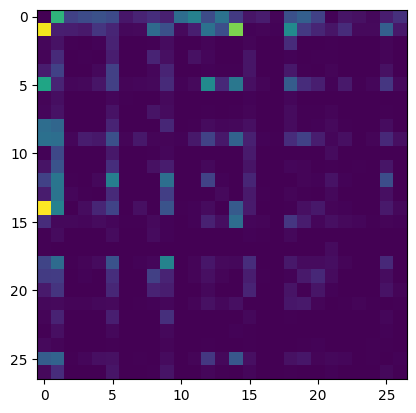

In [24]:
plt.imshow(torch.Tensor.cpu(N))

### Visualization

In [25]:
itos = {i:s for s,i in stoi.items()}

In [26]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

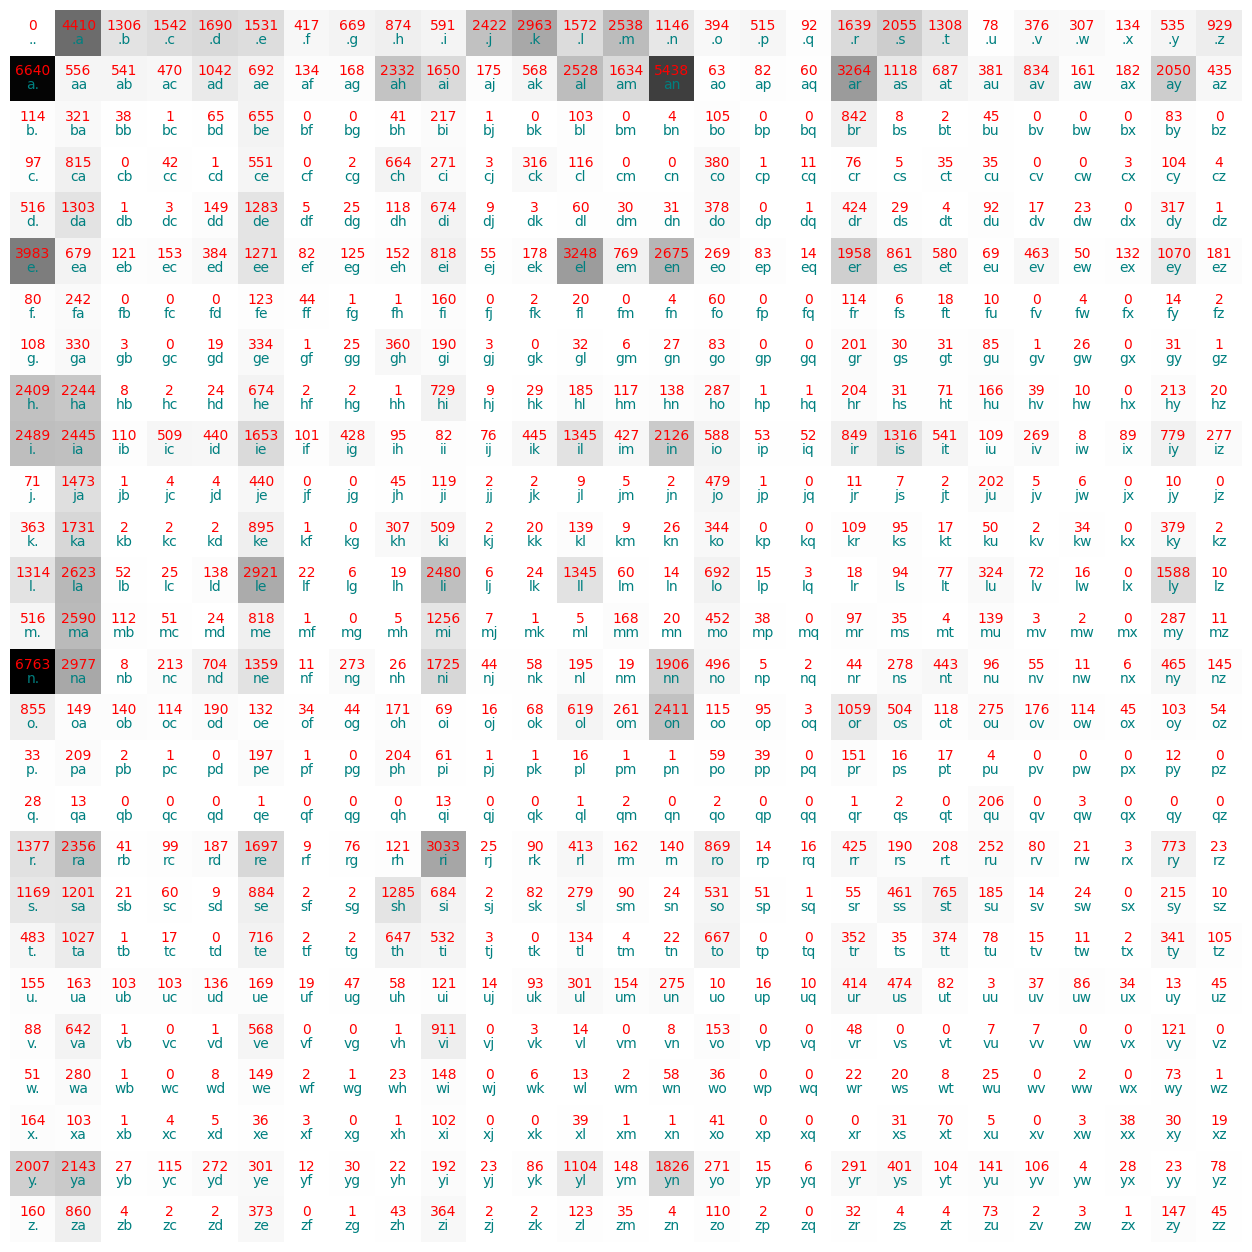

In [27]:
plt.figure(figsize=(16,16))
plt.imshow(torch.Tensor.cpu(N), cmap='Greys')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i,chstr, ha='center', va='top',color='teal')
        plt.text(j,i, N[i,j].item(), ha='center', va='bottom',color='red')
plt.axis('off')

In [28]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [29]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

### Torch.Multinomial

In [30]:
g = torch.Generator().manual_seed(2147483647) #just making it deterministic for smoother outputs
pp = torch.rand(3, generator=g)

In [31]:
pp

tensor([0.7081, 0.3542, 0.1054])

In [32]:
pp = pp / pp.sum()
pp

tensor([0.6064, 0.3033, 0.0903])

In [33]:
torch.multinomial(pp, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

# FOR 2D Array

In [34]:
index = torch.multinomial(p, num_samples=1,replacement=True,generator=g)
index.item()

8

In [35]:
itos[13]

'm'

## THE LOOP

In [36]:
for i in range(20):
    ix = 0
    out = []
    while True:
        p = N[ix].float()
        p = p / p.sum()
        #p = torch.ones(27)/27.0
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

deen.
pereltwnigua.
sadryrolyiniydavesole.
rish.
be.
ka.
nn.
jo.
s.
t.
a.
ze.
brylon.
kymen.
kaedeshaharigaybe.
deyli.
kotallinaler.
d.
eie.
ke.


In [37]:
P = N.float()
P.shape #27,27

torch.Size([27, 27])

In [38]:
P.sum(dim=1,keepdim=True).shape # 27,1

torch.Size([27, 1])

In [39]:
""" Broadcasting Semantics of pytorch 
    is it possible to divide 
    27,27
    27.1
"""

' Broadcasting Semantics of pytorch \n    is it possible to divide \n    27,27\n    27.1\n'

In [40]:
# creating a P: probability distribution of the whole matrix
P = N.float()
P /= P.sum(dim=1,keepdim=True)

In [41]:
P[0]

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [42]:
for i in range(10):
    output = []
    index = 0
    while True:
        p = P[index]
        index = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        output.append(itos[index])
        if index == 0:
            break
    print(''.join(output))      

s.
s.
ki.
olyvitay.
ren.
balyduwyurighan.
e.
esuce.
mo.
duie.


In [43]:
# log(a*b*c) = log(a) + log(b) + log(c)

In [44]:
log_likelihood = 0.0
n = 0
for w in words:
	chs = ['.'] + list(w) + ['.']
	for ch1,ch2 in zip(chs,chs[1:]):
		ix1 = stoi[ch1]
		ix2 = stoi[ch2]
		prob = P[ix1,ix2]
		n += 1
		log_likelihood += torch.log(prob)

print(f"{log_likelihood=:.4f}")
nll = -log_likelihood
print(f"Negative LL = {nll}")
Average_NLL = nll/n
print(f"{Average_NLL=}")

log_likelihood=-559891.7500
Negative LL = 559891.75
Average_NLL=tensor(2.4541)


# Taking a Neural Nets Approach

In [45]:
xs, ys = [],[]

In [46]:
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)
print(xs,ys)  

tensor([ 0,  5, 13, 13,  1]) tensor([ 5, 13, 13,  1,  0])


In [47]:
xs.dtype

torch.int64

In [48]:
import torch.nn.functional as F

In [49]:
xsenc = F.one_hot(xs,num_classes=27).float()

In [50]:
xsenc.dtype

torch.float32

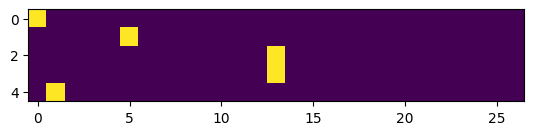

In [51]:
plt.imshow(xsenc)

In [52]:
xsenc.shape

torch.Size([5, 27])

In [53]:
W = torch.randn((27,27),generator=g)
W

tensor([[ 1.5358e+00, -6.3660e-01, -5.1113e-01, -8.3634e-01,  5.3433e-01,
         -9.0516e-01, -2.3645e+00, -8.1808e-01,  1.9373e+00, -1.3100e+00,
          4.8238e-01, -1.2029e+00, -3.1857e-01, -5.3651e-01, -3.3029e-01,
         -5.0230e-01,  7.2999e-01,  7.7843e-01, -1.5188e-01,  8.6024e-02,
         -4.3832e-01,  5.0514e-01, -9.2532e-01,  7.6476e-01,  1.5414e+00,
         -7.7247e-01, -5.4477e-01],
        [-7.6888e-01,  1.2865e+00,  1.0820e+00,  2.1955e-01,  1.0628e+00,
          1.5296e+00, -8.3310e-01,  1.0103e+00,  1.2371e+00, -1.0124e+00,
         -7.1445e-02, -4.5307e-01,  4.5828e-01, -1.3839e+00, -1.1326e+00,
         -1.1447e-01, -4.4096e-01,  1.9424e-01, -5.6857e-01,  3.3530e-01,
          5.1360e-01,  1.3007e+00,  1.2855e+00,  3.1432e-01,  1.1921e+00,
         -1.5575e+00,  3.5758e-01],
        [-1.2753e+00, -3.4627e-01,  5.5251e-02, -2.1752e-01,  1.4209e+00,
          2.1057e+00, -8.9547e-01, -2.7757e-01, -5.7194e-01,  1.1911e+00,
          1.2626e+00,  1.5650e+00,  2.69

In [54]:
logits = xsenc @ W # log-counts to convert negative into postive numbers 
logits

tensor([[ 1.5358, -0.6366, -0.5111, -0.8363,  0.5343, -0.9052, -2.3645, -0.8181,
          1.9373, -1.3100,  0.4824, -1.2029, -0.3186, -0.5365, -0.3303, -0.5023,
          0.7300,  0.7784, -0.1519,  0.0860, -0.4383,  0.5051, -0.9253,  0.7648,
          1.5414, -0.7725, -0.5448],
        [ 0.2405, -0.6171,  0.9078,  0.6119,  0.4035, -0.2953,  0.5616,  0.1641,
         -0.1739,  0.7226, -1.6061,  0.4799,  0.5613, -0.8262,  0.1241,  0.0045,
         -0.3587, -1.7133, -0.3088, -0.6472, -0.2462,  0.2371,  0.6428,  0.1248,
         -0.3294, -0.5307,  0.4699],
        [ 0.9201, -1.4143, -0.1222, -0.9873, -0.4048,  0.7905, -1.5632,  0.8583,
          1.2823,  0.6769,  1.5127, -0.9080,  0.4869, -0.6245, -0.9977, -0.9625,
         -0.6844,  1.0311,  0.1126, -0.1530,  0.3333,  2.0842, -1.9406, -0.7503,
          0.0145,  1.8720,  1.1222],
        [ 0.9201, -1.4143, -0.1222, -0.9873, -0.4048,  0.7905, -1.5632,  0.8583,
          1.2823,  0.6769,  1.5127, -0.9080,  0.4869, -0.6245, -0.9977, -0.9625

In [55]:
counts = logits.exp() # Eqivalent to N
counts

tensor([[4.6451, 0.5291, 0.5998, 0.4333, 1.7063, 0.4045, 0.0940, 0.4413, 6.9403,
         0.2698, 1.6199, 0.3003, 0.7272, 0.5848, 0.7187, 0.6051, 2.0751, 2.1780,
         0.8591, 1.0898, 0.6451, 1.6572, 0.3964, 2.1485, 4.6710, 0.4619, 0.5800],
        [1.2719, 0.5395, 2.4789, 1.8440, 1.4971, 0.7443, 1.7535, 1.1783, 0.8404,
         2.0597, 0.2007, 1.6159, 1.7529, 0.4377, 1.1321, 1.0045, 0.6986, 0.1803,
         0.7344, 0.5235, 0.7818, 1.2676, 1.9017, 1.1329, 0.7193, 0.5882, 1.5998],
        [2.5096, 0.2431, 0.8850, 0.3726, 0.6671, 2.2044, 0.2095, 2.3590, 3.6049,
         1.9678, 4.5389, 0.4033, 1.6273, 0.5355, 0.3687, 0.3819, 0.5044, 2.8042,
         1.1191, 0.8581, 1.3955, 8.0380, 0.1436, 0.4722, 1.0146, 6.5012, 3.0716],
        [2.5096, 0.2431, 0.8850, 0.3726, 0.6671, 2.2044, 0.2095, 2.3590, 3.6049,
         1.9678, 4.5389, 0.4033, 1.6273, 0.5355, 0.3687, 0.3819, 0.5044, 2.8042,
         1.1191, 0.8581, 1.3955, 8.0380, 0.1436, 0.4722, 1.0146, 6.5012, 3.0716],
        [0.4635, 3.6202,

In [56]:
probs = counts / counts.sum(1, keepdim=True) 
probs

tensor([[0.1243, 0.0142, 0.0160, 0.0116, 0.0456, 0.0108, 0.0025, 0.0118, 0.1857,
         0.0072, 0.0433, 0.0080, 0.0195, 0.0156, 0.0192, 0.0162, 0.0555, 0.0583,
         0.0230, 0.0292, 0.0173, 0.0443, 0.0106, 0.0575, 0.1250, 0.0124, 0.0155],
        [0.0417, 0.0177, 0.0813, 0.0605, 0.0491, 0.0244, 0.0575, 0.0387, 0.0276,
         0.0676, 0.0066, 0.0530, 0.0575, 0.0144, 0.0371, 0.0330, 0.0229, 0.0059,
         0.0241, 0.0172, 0.0256, 0.0416, 0.0624, 0.0372, 0.0236, 0.0193, 0.0525],
        [0.0514, 0.0050, 0.0181, 0.0076, 0.0137, 0.0452, 0.0043, 0.0483, 0.0739,
         0.0403, 0.0930, 0.0083, 0.0333, 0.0110, 0.0076, 0.0078, 0.0103, 0.0575,
         0.0229, 0.0176, 0.0286, 0.1647, 0.0029, 0.0097, 0.0208, 0.1332, 0.0629],
        [0.0514, 0.0050, 0.0181, 0.0076, 0.0137, 0.0452, 0.0043, 0.0483, 0.0739,
         0.0403, 0.0930, 0.0083, 0.0333, 0.0110, 0.0076, 0.0078, 0.0103, 0.0575,
         0.0229, 0.0176, 0.0286, 0.1647, 0.0029, 0.0097, 0.0208, 0.1332, 0.0629],
        [0.0100, 0.0779,

In [57]:
probs[0].sum(0)

tensor(1.0000)

In [58]:
f_xs = [] # A INPUT
f_ys = [] # A LABEL

In [59]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        f_xs.append(ix1)
        ix2 = stoi[ch2]
        f_ys.append(ix2)

In [60]:
f_xs = torch.tensor(f_xs)
f_ys = torch.tensor(f_ys)

In [61]:
f_xs_enc = F.one_hot(f_xs,num_classes=27).float()

In [62]:
W = torch.randn((27,27), generator=g)

In [63]:
logits = f_xs_enc @ W  #log-equivalents 27x27 matrix

In [64]:
counts = logits.exp() # N equivalent to the statistical model

In [65]:
prob = counts / counts.sum(1, keepdim=True) # probabilities for the next character

In [66]:
prob[0].sum()

tensor(1.0000)

In [67]:
fnlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print('------')
    print(f'bigram example, {i+1}: {itos[x]} {itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilites from the neural net:', prob[i])
    print('label (actual next character): ', y)

    p = probs[i,y]
    print('Probability assigned by the net to the correct character:', p.item())
    logp= torch.log(p)
    print('log likelihood :', logp.item())
    fnll = -logp.item()
    print('negative log likelihood: ', fnll)
    fnlls[i] = fnll

print('===')
print('average nevative log likelihood, i.e loss=',fnlls.mean().item())

------
bigram example, 1: . e (indexes 0,5)
input to the neural net: 0
output probabilites from the neural net: tensor([0.0658, 0.0705, 0.0047, 0.0141, 0.1038, 0.0127, 0.1011, 0.0118, 0.0112,
        0.0161, 0.0095, 0.0058, 0.0074, 0.0170, 0.1003, 0.0113, 0.0586, 0.0187,
        0.0471, 0.0418, 0.0461, 0.0227, 0.0273, 0.0349, 0.0784, 0.0250, 0.0366])
label (actual next character):  5
Probability assigned by the net to the correct character: 0.01082022488117218
log likelihood : -4.52633810043335
negative log likelihood:  4.52633810043335
------
bigram example, 2: e m (indexes 5,13)
input to the neural net: 5
output probabilites from the neural net: tensor([0.0063, 0.0232, 0.0096, 0.0072, 0.0619, 0.0441, 0.0860, 0.0260, 0.0032,
        0.0446, 0.0751, 0.0027, 0.0983, 0.0278, 0.0529, 0.0196, 0.0077, 0.0213,
        0.1535, 0.0456, 0.0301, 0.0119, 0.0233, 0.0249, 0.0415, 0.0413, 0.0106])
label (actual next character):  13
Probability assigned by the net to the correct character: 0.01436040

# Manual Optimization

In [68]:
xs

tensor([ 0,  5, 13, 13,  1])

In [69]:
ys

tensor([ 5, 13, 13,  1,  0])

In [70]:
g =  torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad = True)

In [71]:
#Forward Pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(5),ys].log().mean()

In [72]:
print(loss.item())

3.7693049907684326


In [73]:
#Backward Pass
W.grad = None
loss.backward()

In [74]:
#Update
W.data += -0.1 * W.grad

# OPTIMIZATION

In [103]:
device = ("cuda" if torch.cuda.is_available else "cpu")
device = "cpu"

In [104]:
# DATASET
fxs = []
fys = []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        fxs.append(ix1)
        fys.append(ix2)
        
fxs = torch.tensor(fxs).to(device)
fys = torch.tensor(fxs).to(device)
num = fxs.nelement()
print("Number of examples :", num)

#Initializing Network
seed = torch.Generator().manual_seed(214783647)
WW = torch.randn((27,27), generator=seed, requires_grad=True).to(device)    

Number of examples : 228146


/tmp/ipykernel_14058/1530323511.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fys = torch.tensor(fxs).to(device)


In [107]:
WW

tensor([[-0.0619, -1.5577,  0.0054,  0.4544,  0.4921, -0.1450,  0.3035,  0.2176,
          0.7965,  0.7460, -0.9886,  0.0582,  0.1999,  1.3672,  1.6599,  0.3868,
          0.5312,  0.4083,  1.5269,  0.9386, -0.7099,  0.9888, -0.5241,  1.4551,
          1.0090, -0.9325, -1.5061],
        [-1.3356, -0.3226,  1.2575,  0.2692, -0.5664,  0.4996,  1.8135,  1.0449,
          1.5089,  0.1522,  1.6345,  0.6542,  0.1369, -0.3220,  1.9111, -0.8203,
          1.0767,  0.5363, -0.2801, -0.9402,  0.5081,  0.8768,  1.1020,  0.0545,
         -0.2887,  0.0306, -0.5152],
        [-1.6943, -0.3235,  0.8431,  1.3225,  0.0268,  0.1839, -0.8227,  1.7475,
         -0.2051,  0.2663,  0.0298, -0.5716,  0.7727,  0.3682,  0.5667,  1.2023,
          1.6217, -0.6245, -1.8232, -0.6136,  0.8323,  0.2296, -1.3147,  0.2107,
         -0.0640, -0.2409,  0.2499],
        [ 1.1988,  1.9245, -0.6289,  0.4858,  1.0338, -0.5431,  0.0158,  0.0570,
         -1.6546,  1.3270, -1.8604,  0.3792, -1.5980,  0.5966,  1.8854,  1.2185

In [108]:
#gradient descent 

for k in range(250):

    #forward pass
    fxs_enc = F.one_hot(fxs, num_classes=27).float()
    logits = fxs_enc @ WW 
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), fys].log().mean() + 0.01 * (W**2).mean()
    print(loss.item())

    #backward pass
    WW.grad = None
    loss.backward()

    #Update
    WW.data += -0.1 * WW.grad

4.0033369064331055
3.9953391551971436
3.9873459339141846
3.979355812072754
3.971370220184326
3.963388204574585
3.9554100036621094
3.9474363327026367
3.939466714859009
3.9315011501312256
3.9235401153564453
3.9155828952789307
3.90762996673584
3.899681329727173
3.891737461090088
3.8837976455688477
3.8758625984191895
3.867931604385376
3.8600058555603027
3.852083921432495
3.8441667556762695
3.836254596710205
3.8283464908599854
3.820444107055664
3.8125460147857666
3.8046531677246094
3.796764612197876
3.788881540298462
3.7810027599334717
3.773129463195801
3.765261173248291
3.7573976516723633
3.749540090560913
3.741687774658203
3.733840227127075
3.7259984016418457
3.7181615829467773
3.7103302478790283
3.7025043964385986
3.6946847438812256
3.6868703365325928
3.6790614128112793
3.6712582111358643
3.6634609699249268
3.6556692123413086
3.6478841304779053
3.6401045322418213
3.6323304176330566
3.624563217163086
3.616802215576172
3.6090469360351562
3.6012978553771973
3.5935556888580322
3.585818767547

In [109]:
probs[0,5]

tensor(0.0137, grad_fn=<SelectBackward0>)

In [111]:
for i in range(10):

    out = []
    ix = 0
    while True:

        xenc = F.one_hot(torch.tensor([ix]),num_classes=27).float().to(device)
        logits = xenc @ WW
        counts = logits.exp()
        p = counts/counts.sum(1, keepdims=True)
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=seed).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
        

itstpzfxu.
.
.
ghhyzsksgtozsy.
sdriluqciabpqinfaahaaghjowiitdribukgujklqcpmcnaaafbbhvdhmkffboaveuqjvcpmvbahacajveutlpmjdemynk.
.
nttkudrludrsxzoe.
scdlozfvqteekaaxfbozpcdrrimjeov.
hl.
wcoafdhjozjtrreeengjwee.
